In [1]:
from pathlib import Path
import os
import sys
import matplotlib.pyplot as plt
import pandas as pd
from pprint import pprint
from IPython.display import Image, Markdown, display

_here = Path.cwd().resolve()
_repo_root = next(path for path in (_here, *_here.parents) if (path / "configs" / "cfg.py").exists())
os.chdir(_repo_root)
sys.path.insert(0, str(_repo_root))

from data.share_data import load_share_data
from scripts.misocp import plot_misocp_outputs, run_global_misocp_ev
from utils.records import compute_ev_agent_cost_summary, compute_ev_cost_summary
from utils.run_artifacts import load_experiment_context


In [2]:
run_dir = Path("artifacts/runs/20260512_220936_494b4c57")
cfg, run_dir = load_experiment_context(run_dir)
cfg.env.ev_enabled = True
cfg.model.action_dim = 3
cfg.env.ev_departure_constraint_mode = "soft"
cfg.env.ev_hard_projection_enabled = False
cfg.env.ev_emergency_charging_enabled = False
cfg.reward.ev_departure_penalty_weight = 500.0
cfg.env.ev_capacity_kwh = (60.0, 60.0, 60.0)
cfg.env.ev_soc_min = 0.10
cfg.env.ev_soc_max = 0.95
cfg.env.ev_arrival_soc = 0.15
cfg.env.ev_departure_soc_req = 0.90
cfg.env.ev_max_charge_kw = (11.0, 11.0, 11.0)
cfg.env.ev_efficiency = 0.95
cfg.env.ev_arrival_step = 72
cfg.env.ev_departure_step = 28
share_data = load_share_data(run_dir / "share_data", cfg)
display(Markdown("# MADRL_ESS MISOCP + EV Soft Constraint"))
summary = {
    "run_dir": str(run_dir),
    "ev_enabled": bool(cfg.env.ev_enabled),
    "ev_departure_constraint_mode": cfg.env.ev_departure_constraint_mode,
    "action_dim": int(cfg.model.action_dim),
    "ev_capacity_kwh": cfg.env.ev_capacity_kwh,
    "ev_arrival_soc": float(cfg.env.ev_arrival_soc),
    "ev_departure_soc_req": float(cfg.env.ev_departure_soc_req),
    "ev_max_charge_kw": cfg.env.ev_max_charge_kw,
    "ev_arrival_step": int(cfg.env.ev_arrival_step),
    "ev_departure_step": int(cfg.env.ev_departure_step),
}
if cfg.env.ev_departure_constraint_mode == "emergency":
    summary["ev_emergency_window_hours"] = float(cfg.env.ev_emergency_window_hours)
    summary["ev_emergency_strategy"] = cfg.env.ev_emergency_strategy
display(pd.DataFrame([summary]))


# MADRL_ESS MISOCP + EV Soft Constraint

,run_dir,ev_enabled,ev_departure_constraint_mode,action_dim,ev_capacity_kwh,ev_arrival_soc,ev_departure_soc_req,ev_max_charge_kw,ev_arrival_step,ev_departure_step
0,artifacts\runs\20260512_220936_494b4c57,True,soft,3,"(60.0, 60.0, 60.0)",0.15,0.9,"(11.0, 11.0, 11.0)",72,28


In [3]:
record = run_global_misocp_ev(cfg, run_dir, share_data, ev_mode="soft")
display(Markdown("## Metrics"))
display(record["metrics_df"])
display(Markdown("## Agent Summary"))
display(record["rollout"].summary)
pprint({"record_dir": str(record["record_dir"])})

display(Markdown("## Total Cost Summary"))
cost_ts, cost_summary = compute_ev_cost_summary(record["rollout"], cfg)
agent_cost_summary = compute_ev_agent_cost_summary(record["rollout"], cfg)
display(cost_summary)
display(Markdown("### Cost by Agent"))
display(agent_cost_summary)



Global MISOCP + EV Soft Constraint/perfect:   0%|          | 0/15 [00:00<?, ?episode/s]

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2830634
Academic license 2830634 - for non-commercial use only - registered to we___@163.com


## Metrics

,controller,soc_mode,storage_charge_cost_total_eur,storage_discharge_revenue_total_eur,storage_profit_total_eur,storage_objective_total_eur,system_other_cost_eur,total_eur,soc_penalty_total,voltage_penalty_total,...,voltage_step_delta_p95_pu,voltage_step_delta_max_pu,voltage_spread_mean_pu,voltage_spread_max_pu,trafo_overload_steps,trafo_loading_max_pct,feeder_netload_ramp_mean_abs_kw,feeder_netload_ramp_max_kw,battery_net_power_kw_mean_abs,returned_primary_objective_eur
0,Global MISOCP + EV Soft Constraint,continuous,850.375286,1450.460997,600.085711,-600.085711,248.096201,-351.989509,1.894171,0.000088,...,0.017161,0.055753,0.005532,0.03976,0,97.855133,26.8053,293.911026,42.072215,-600.08571


## Agent Summary

...

{'record_dir': 'artifacts\\runs\\20260512_220936_494b4c57\\results\\perfect\\global_misocp_EV_soft\\record'}


## Total Cost Summary

,battery_total_cost_eur,ev_total_cost_eur,pv_total_cost_eur,total_cost_eur,pv_cost_note
0,-600.085709,248.096201,0.0,-351.989509,PV cost currently set to zero unless curtailme...


### Cost by Agent

,agent,battery_cost_eur,ev_cost_eur,pv_cost_eur,total_cost_eur
0,0,-201.867169,82.698731,0.0,-119.168438
1,1,-197.289198,82.698738,0.0,-114.590459
2,2,-200.929342,82.698731,0.0,-118.230611


1. Power balance


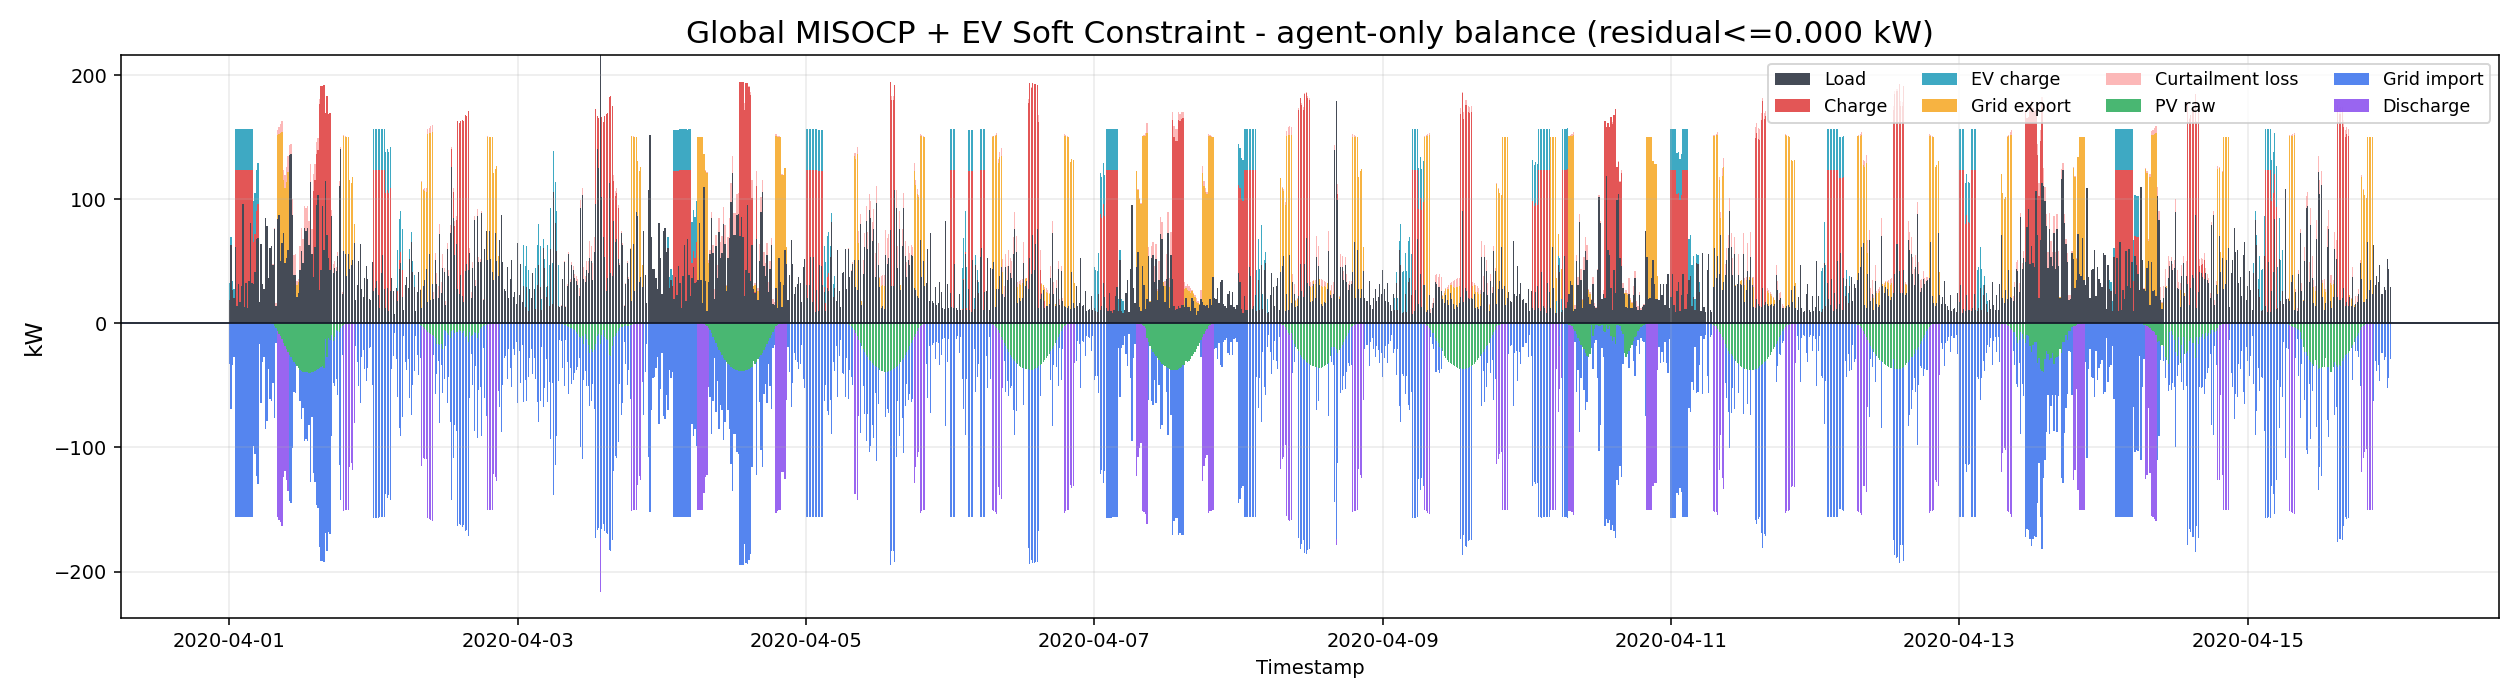

2. Price


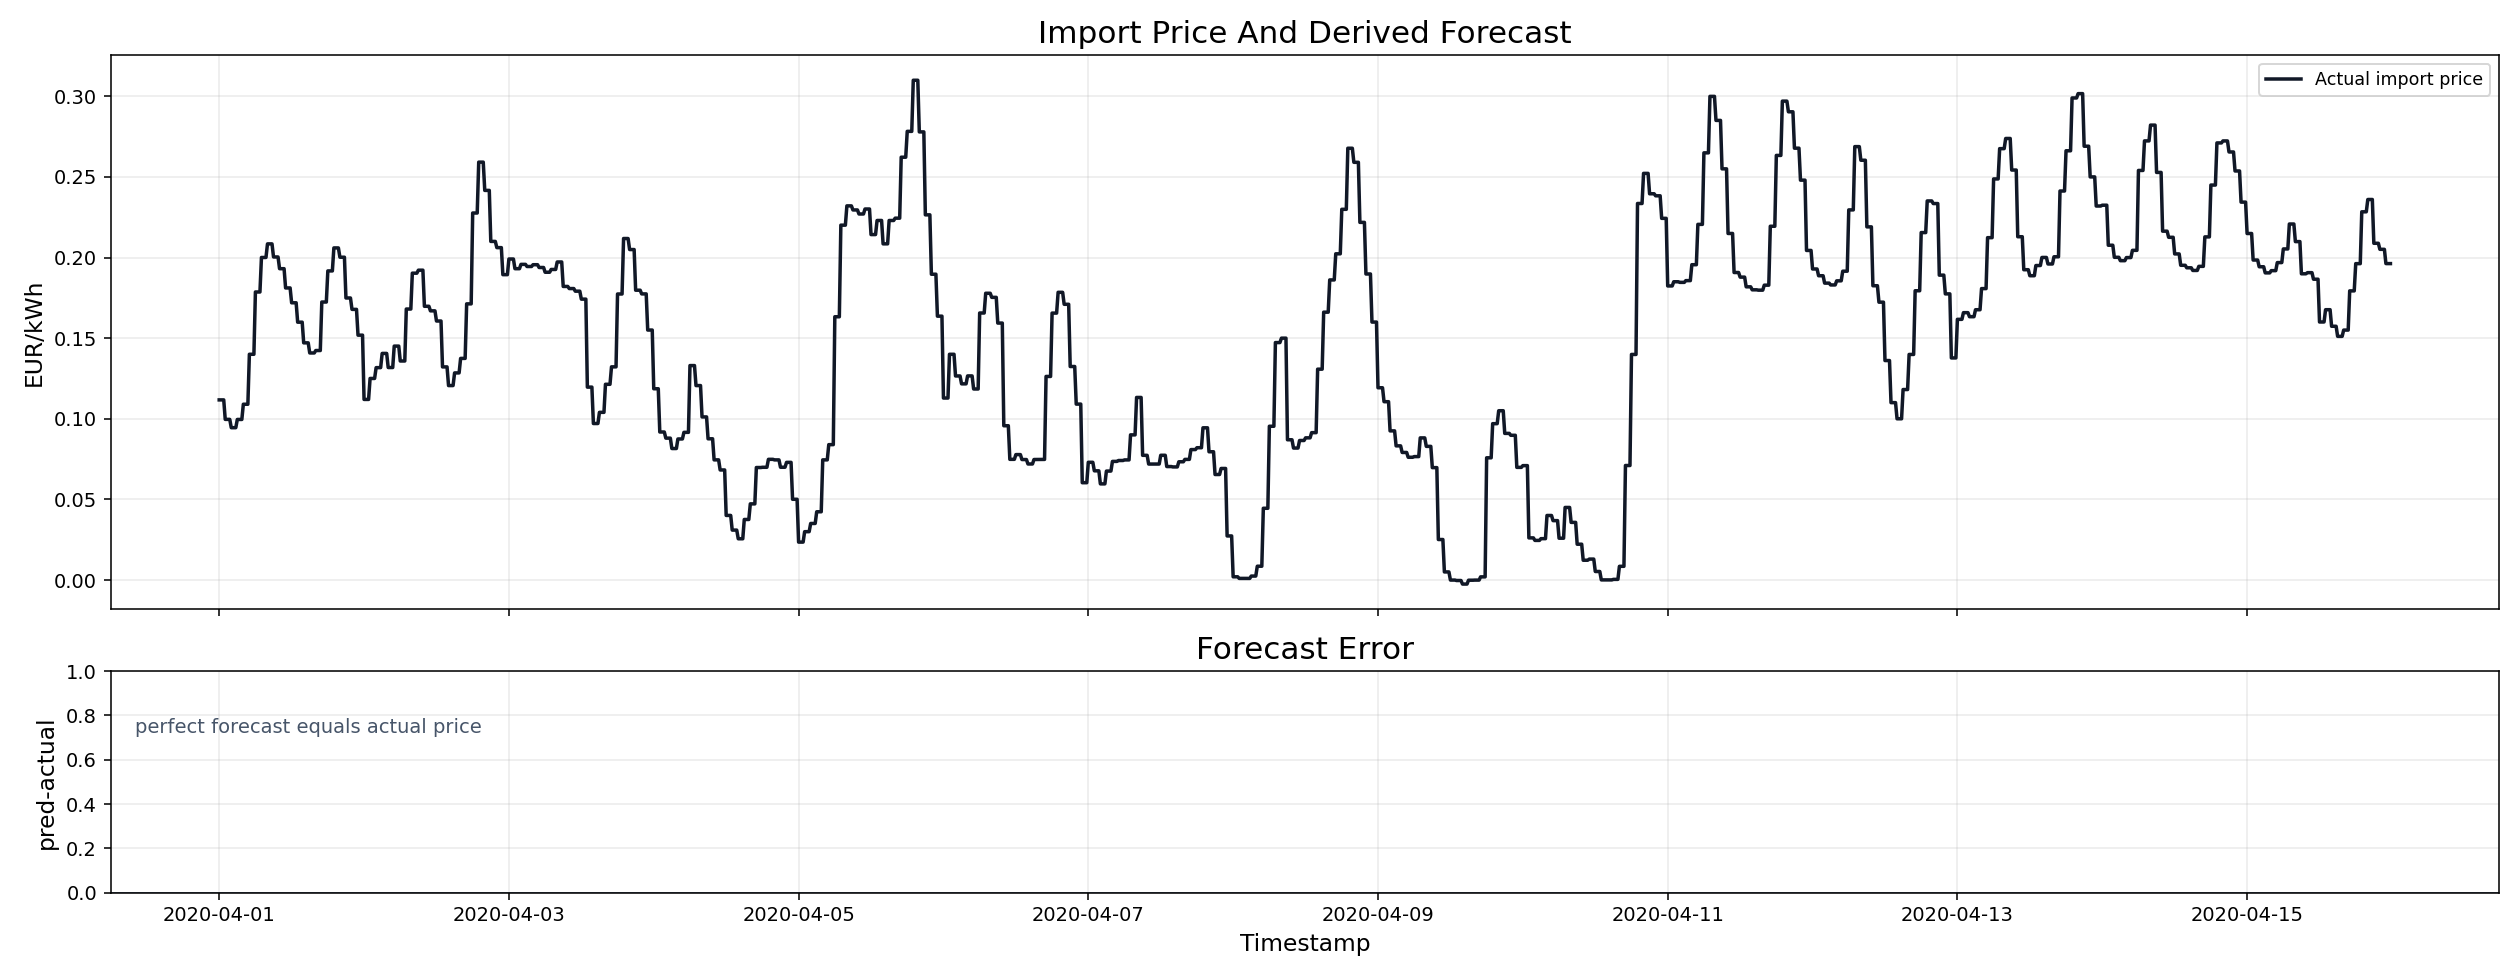

3. Battery power and SoC


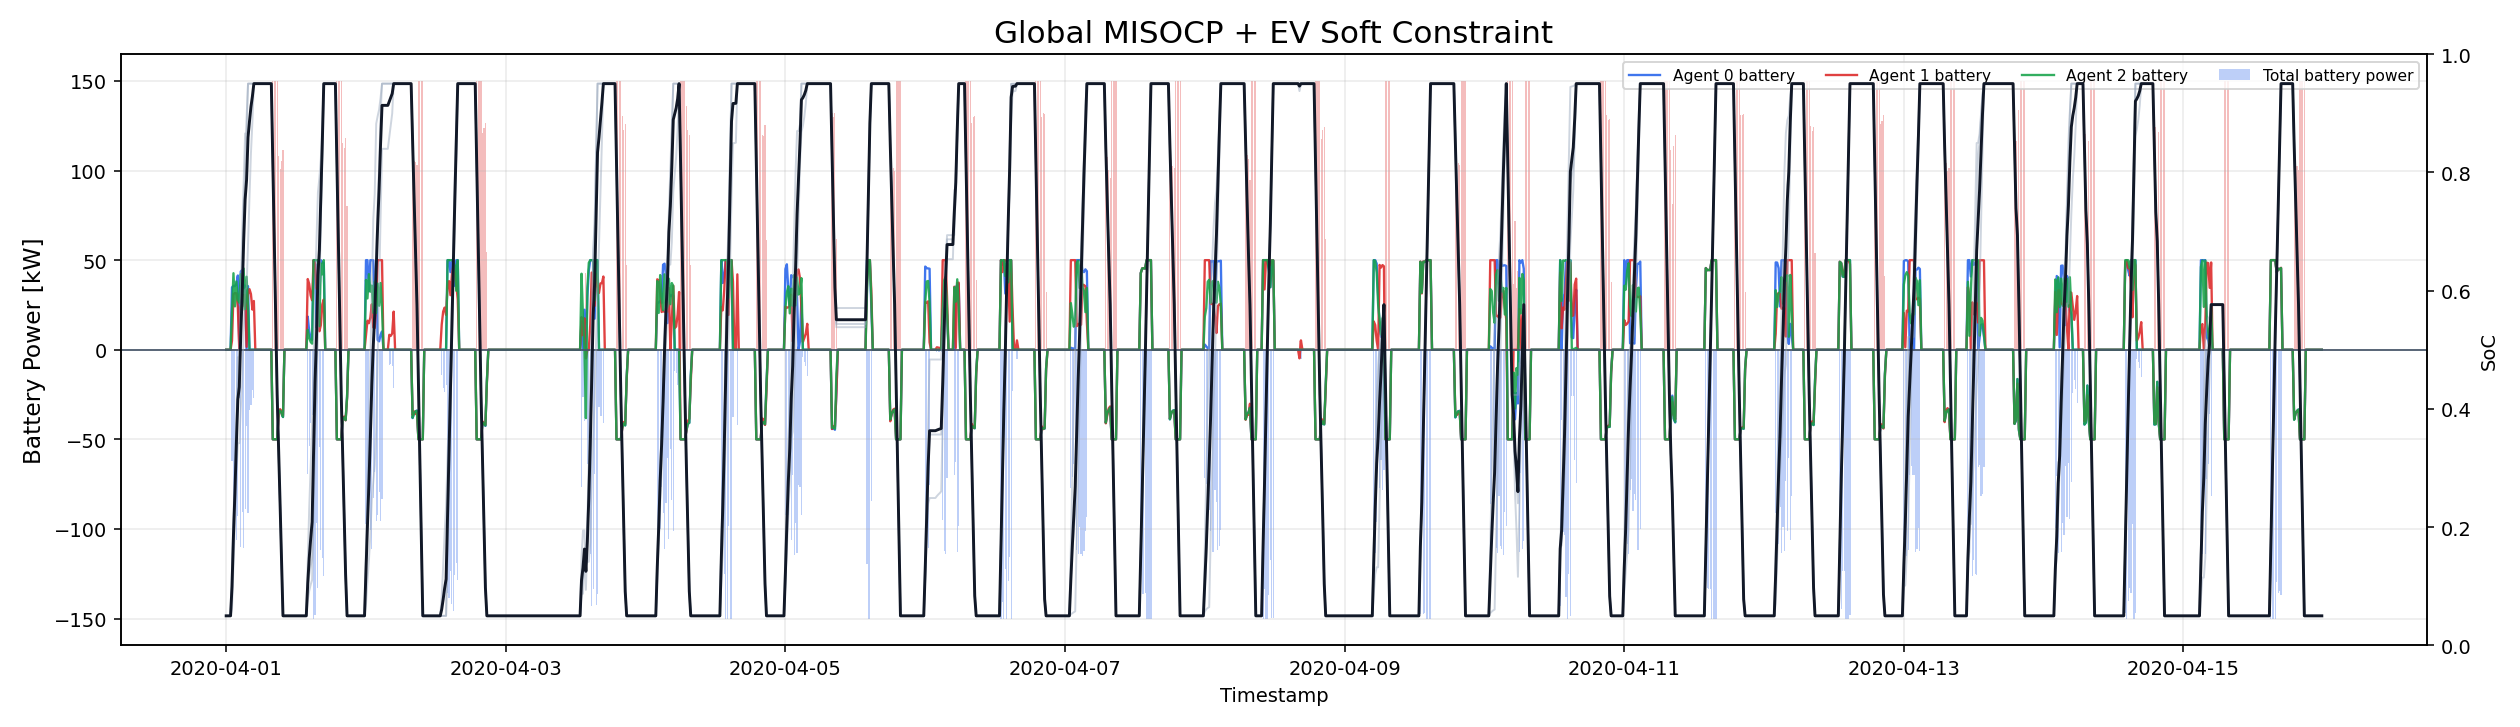

4. Voltage


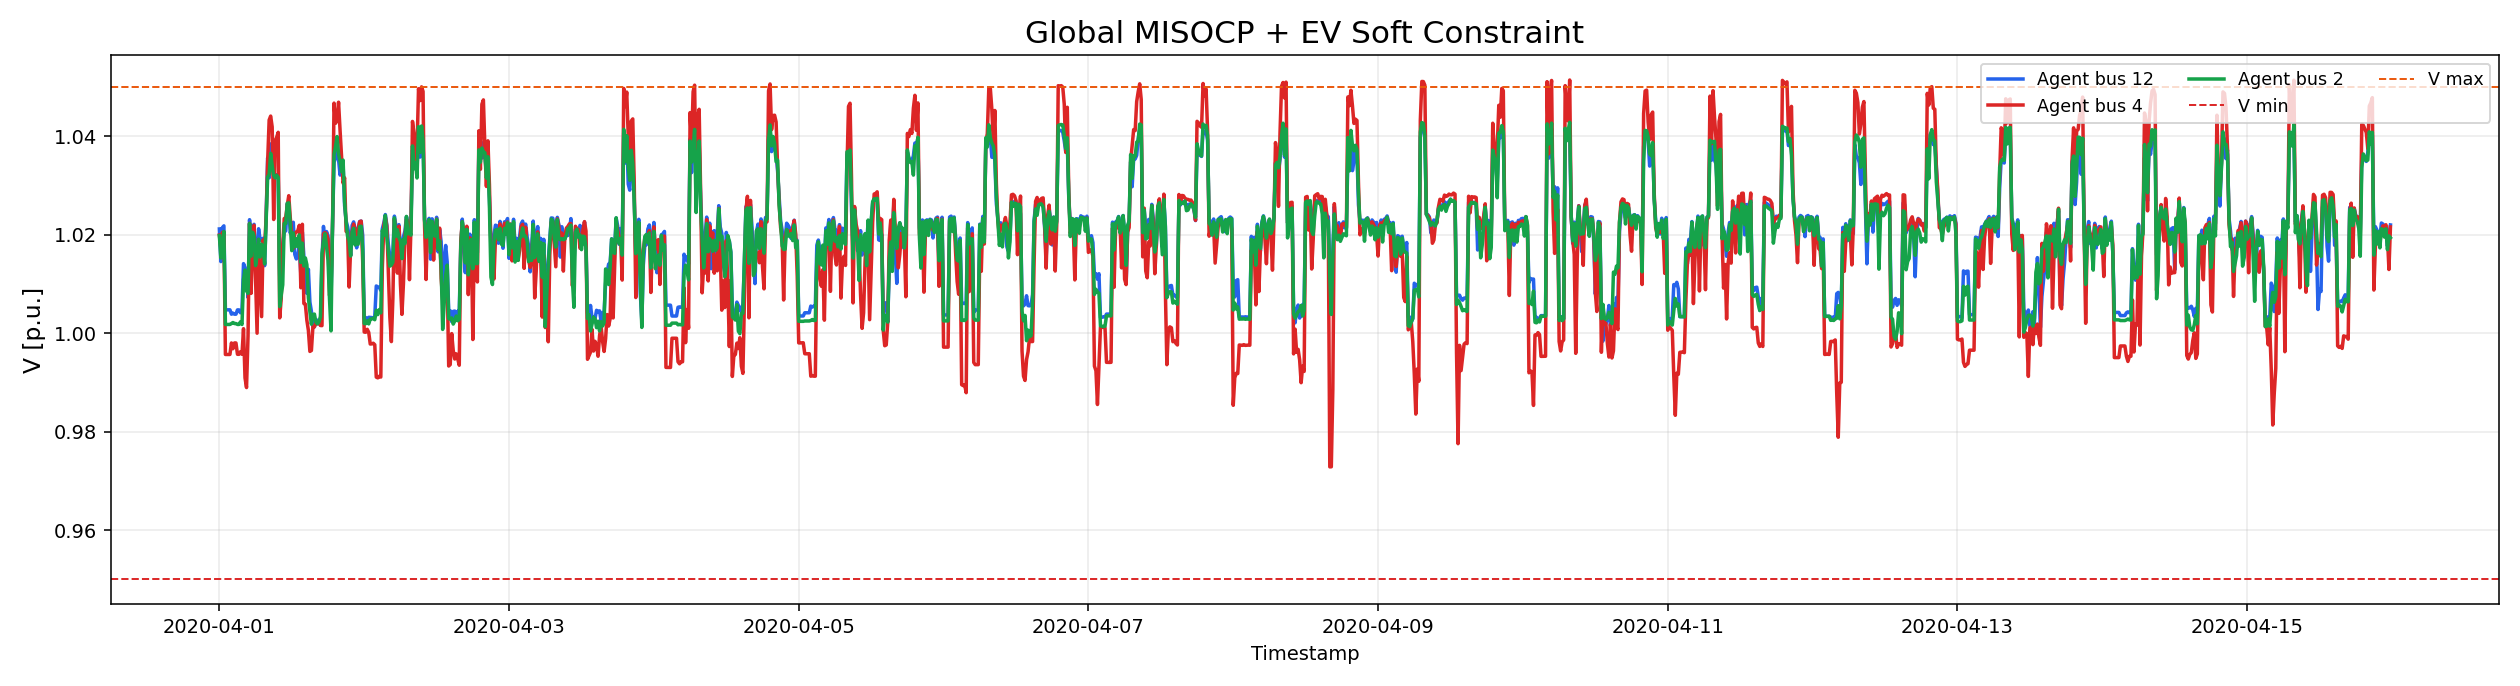

5. Net load


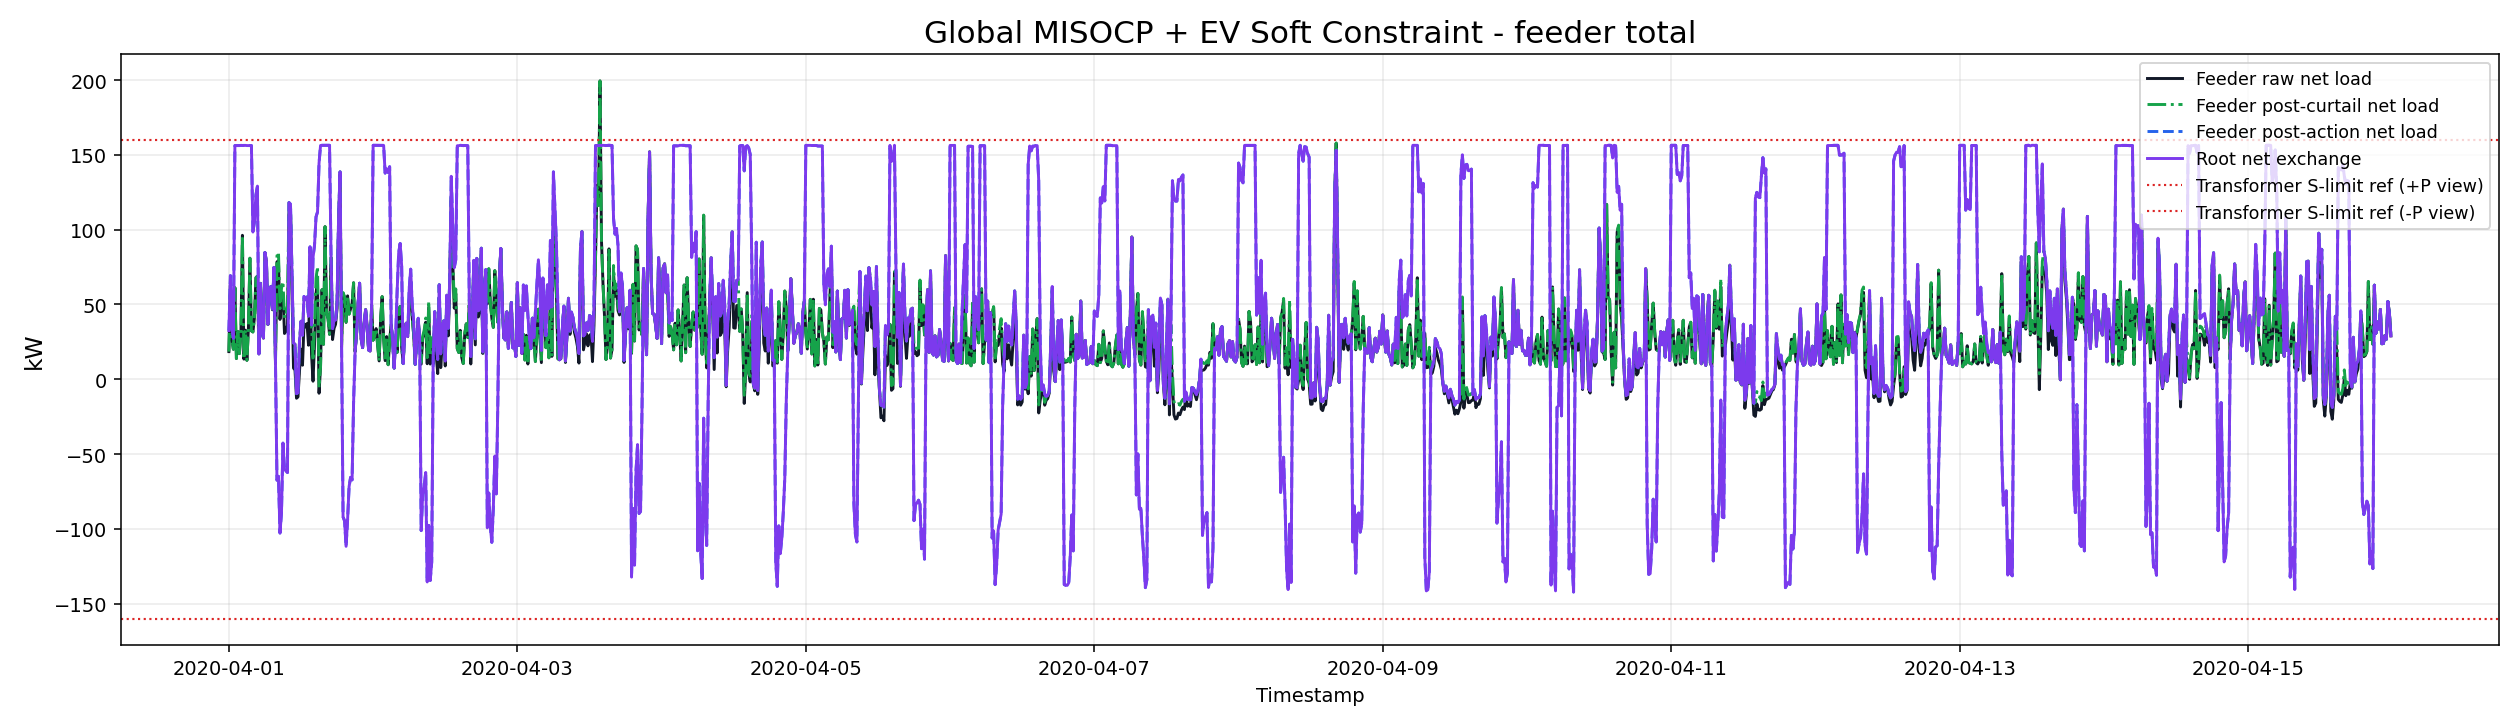

6. EV SOC


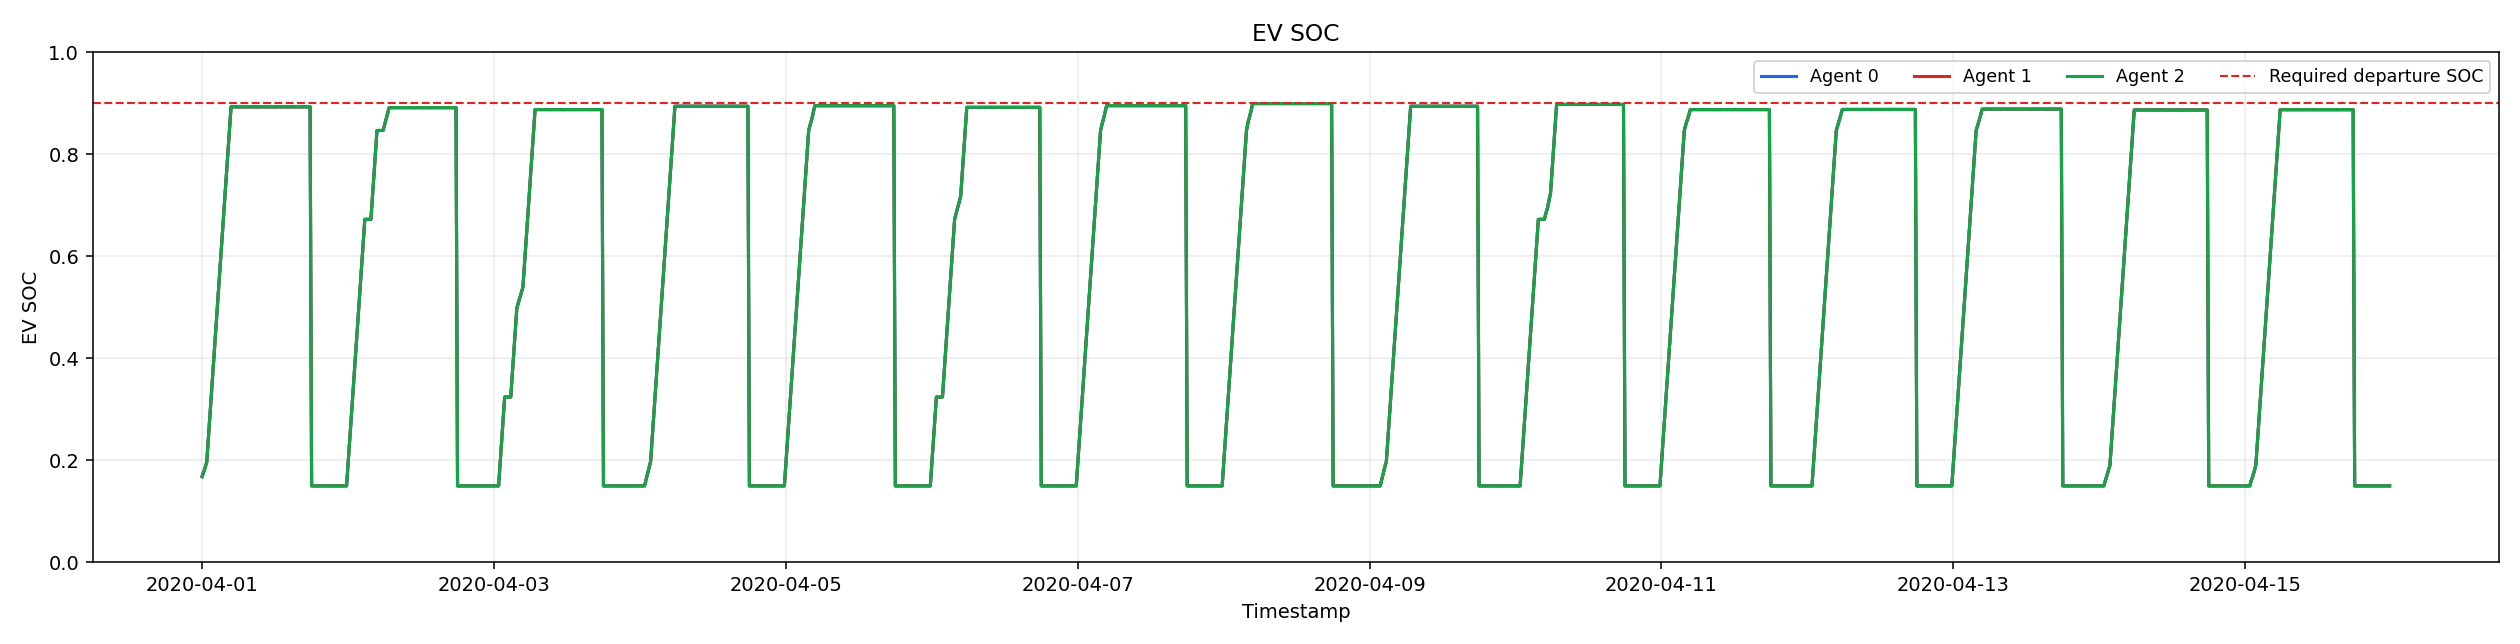

7. EV charging power


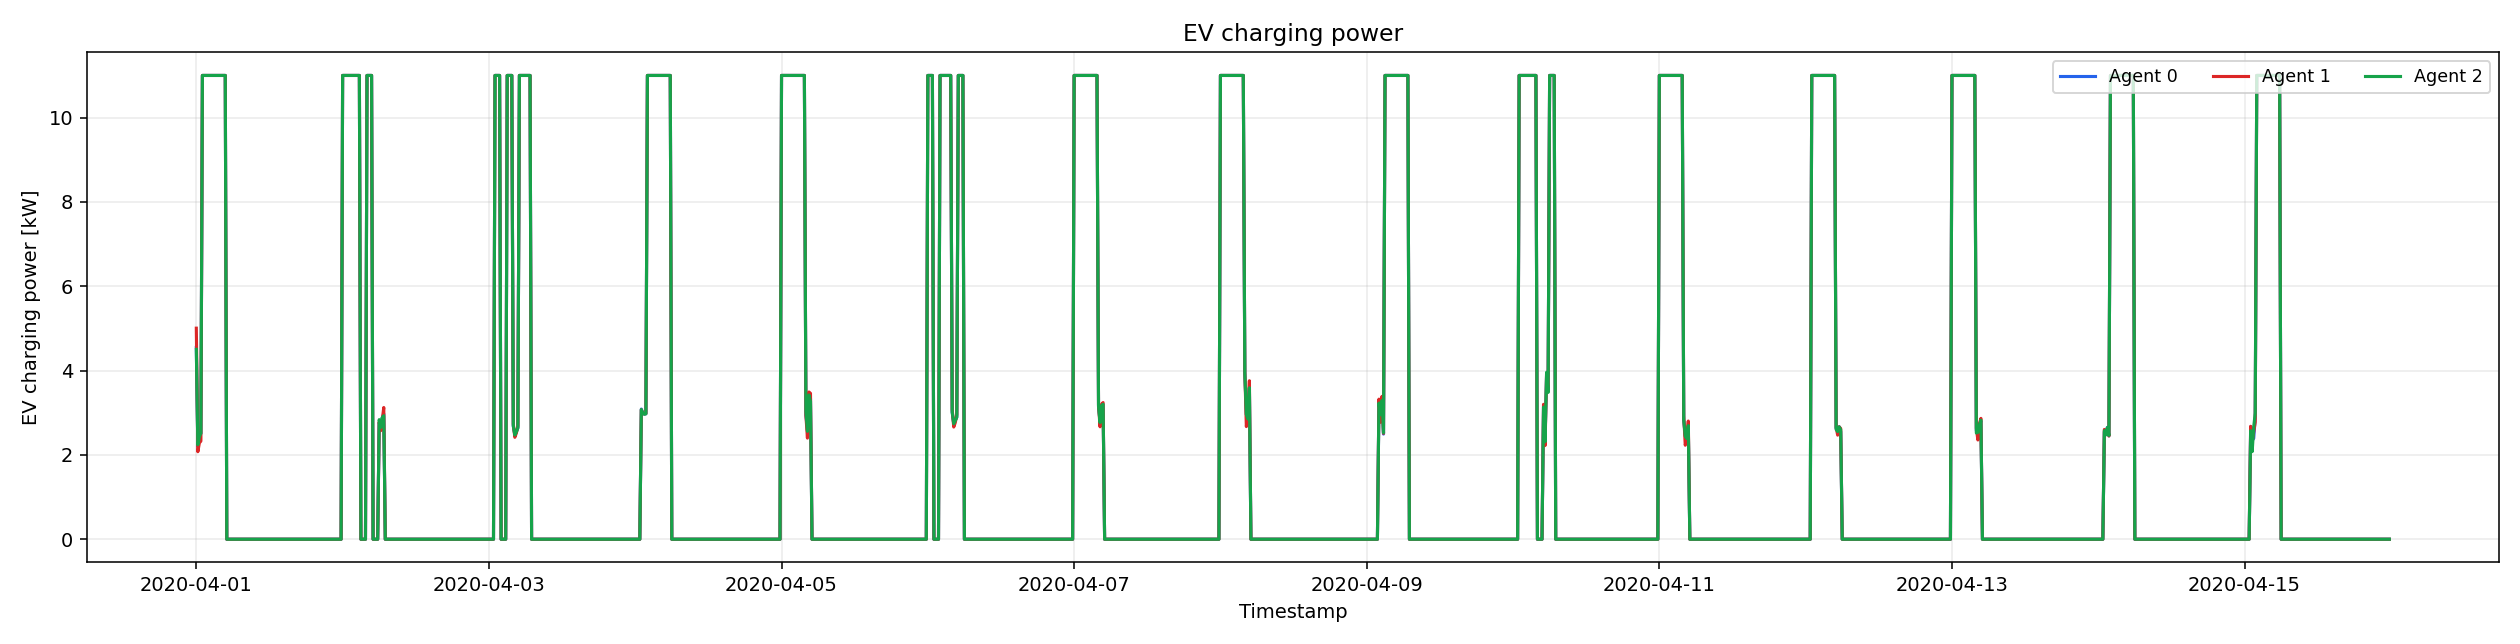

8. EV departure SOC requirement check


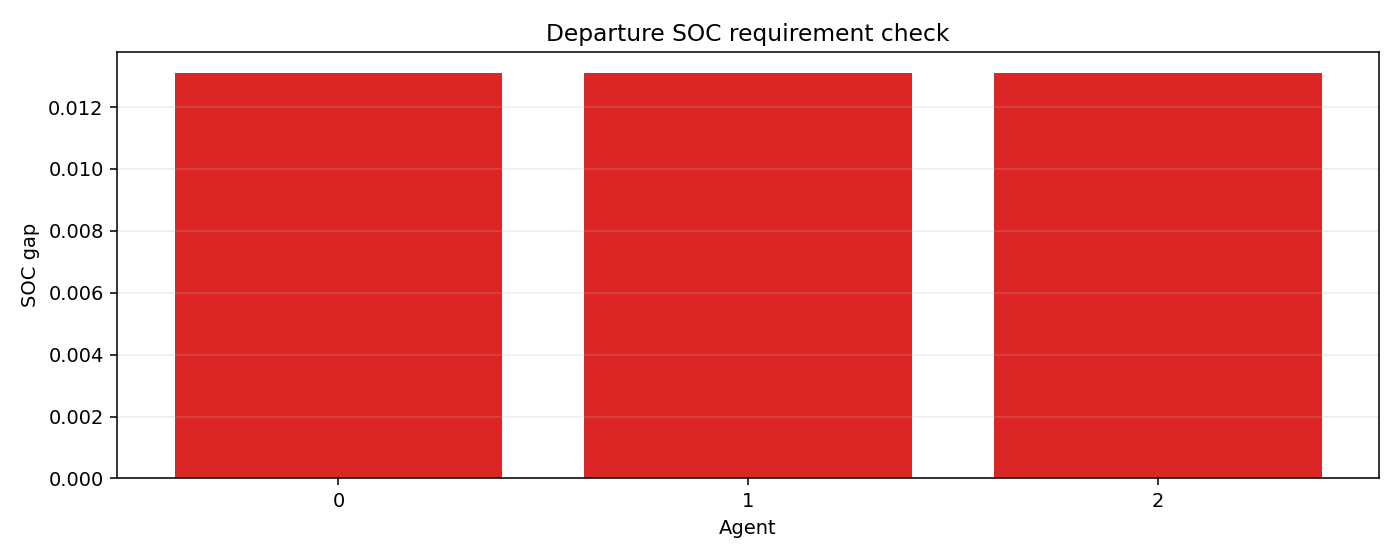

9. Total cumulative cost


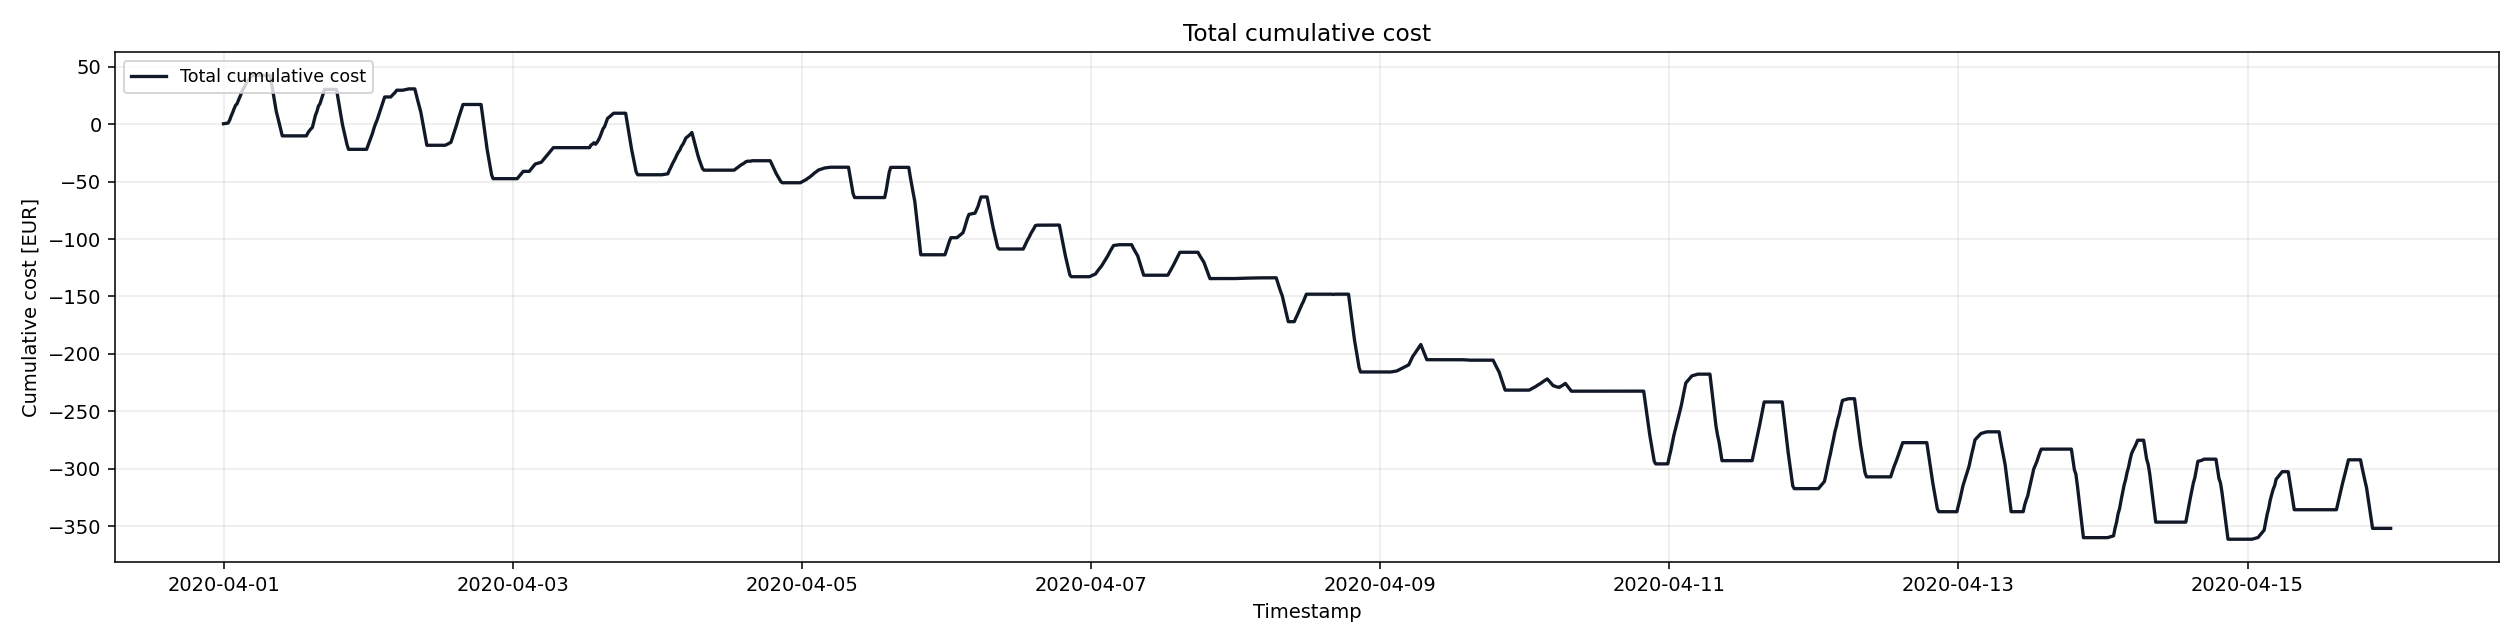

10. Cost components per step


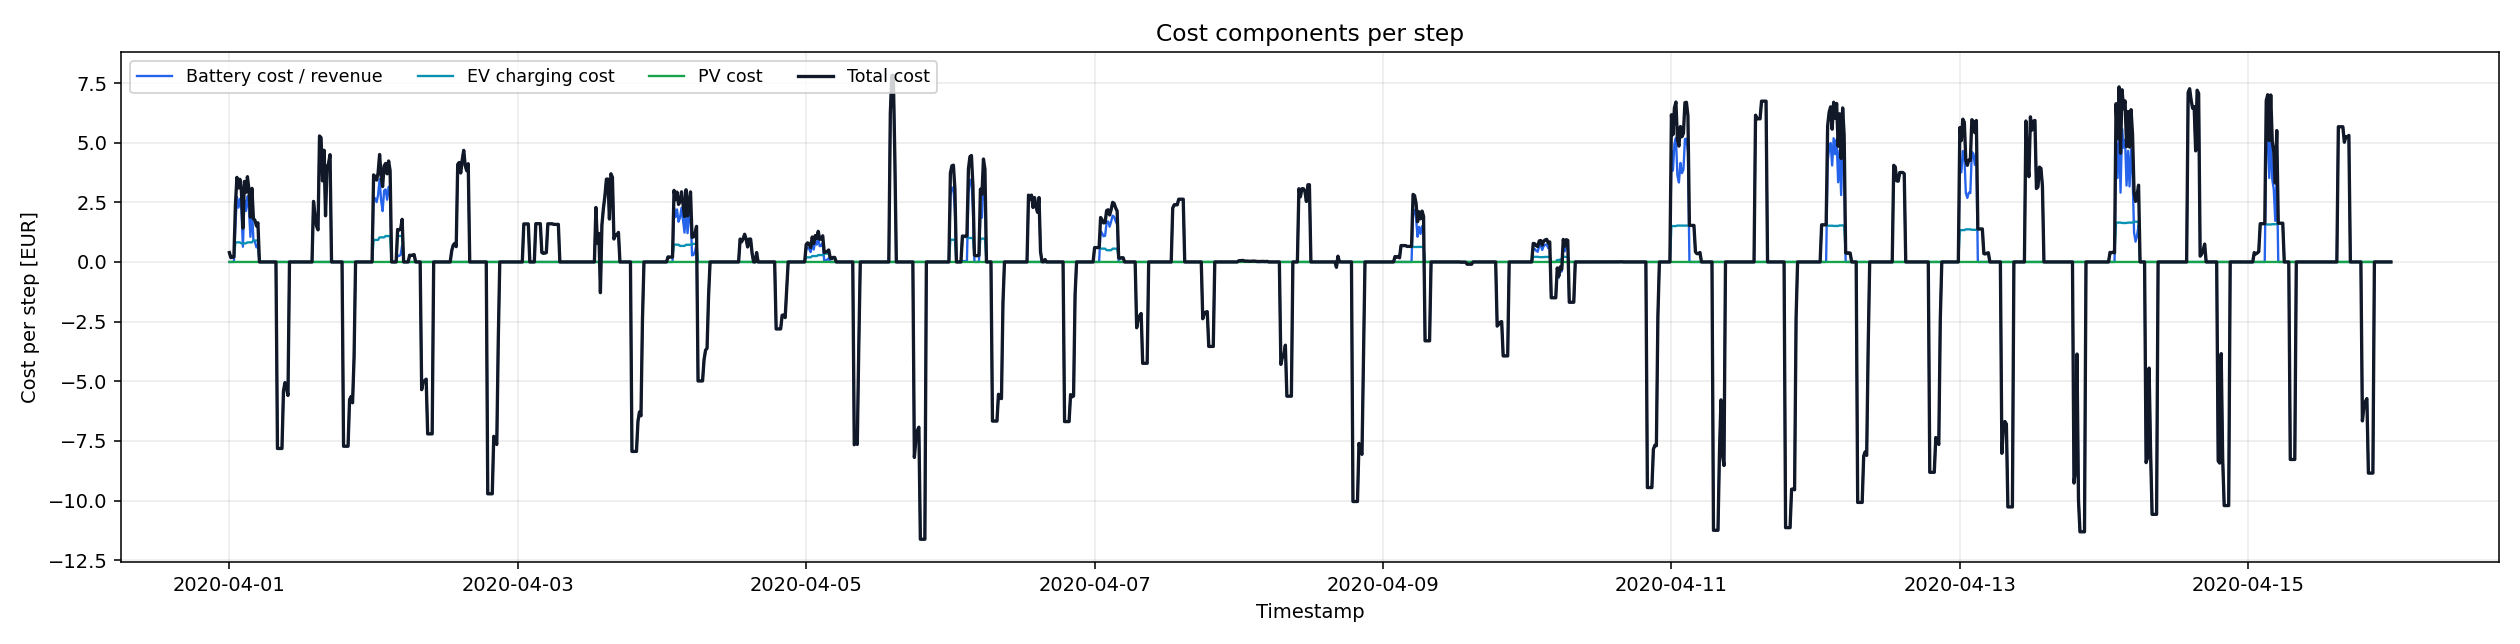

11. Cumulative cost components


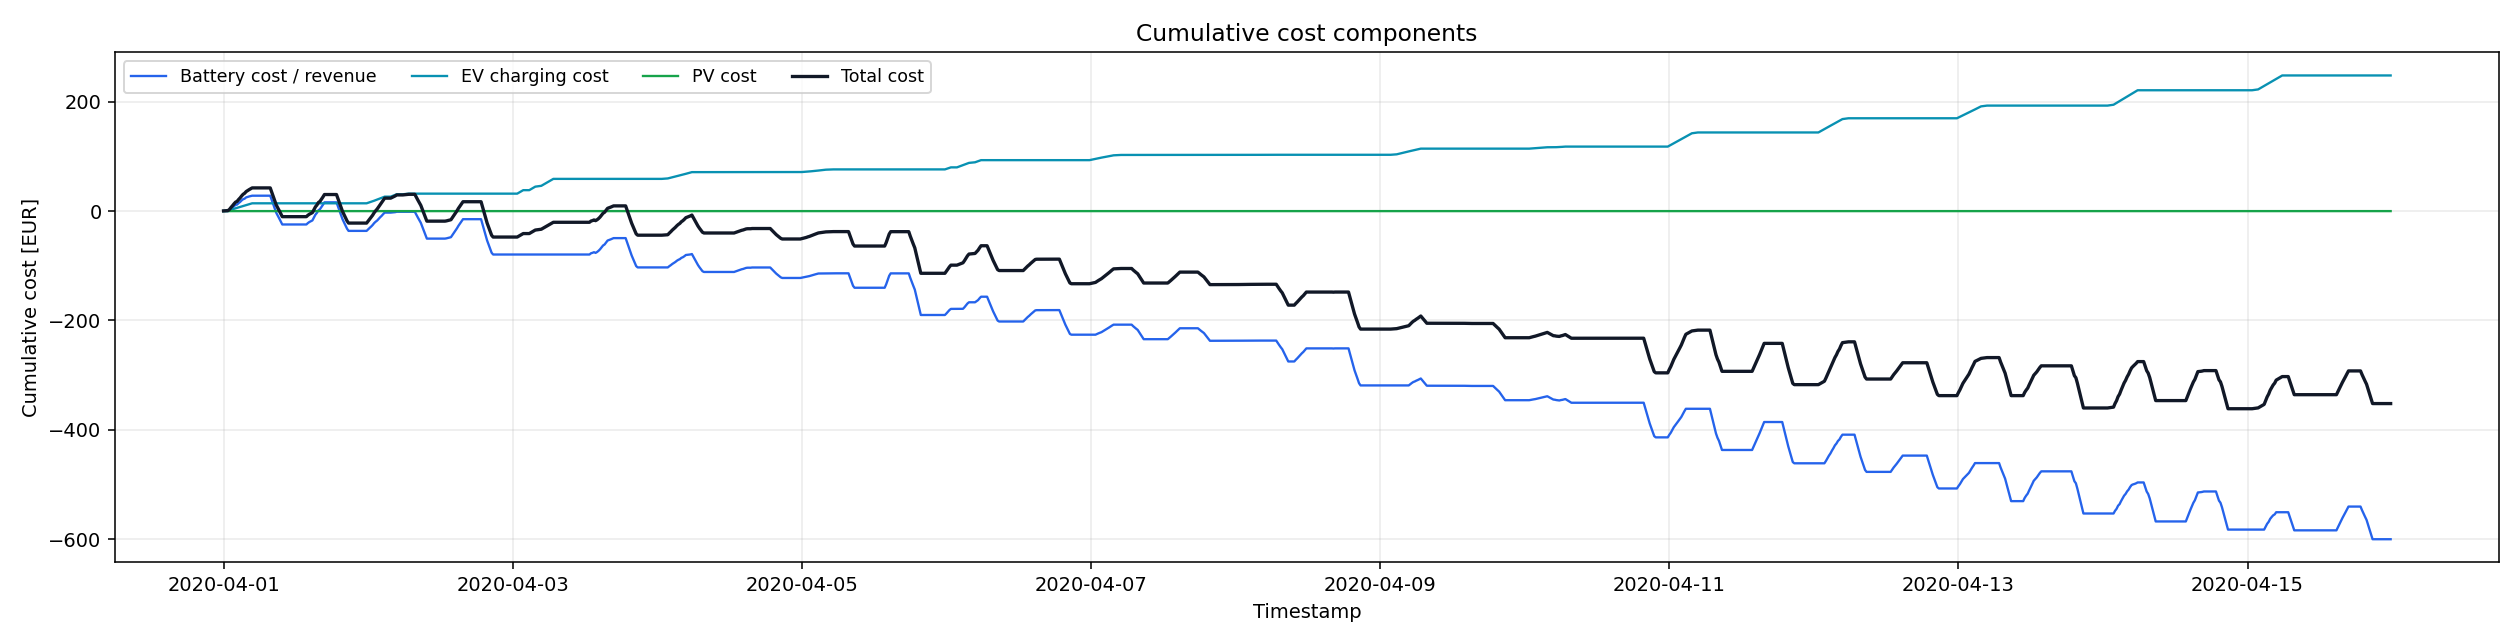

In [4]:
figures = plot_misocp_outputs(record, run_dir)
_plot_specs = [
    ("1. Power balance", "misocp_power_balance"),
    ("2. Price", "misocp_price"),
    ("3. Battery power and SoC", "misocp_battery_soc"),
    ("4. Voltage", "misocp_voltage"),
    ("5. Net load", "misocp_net_load"),
    ("6. EV SOC", "misocp_ev_soc"),
    ("7. EV charging power", "misocp_ev_charge_kw"),
    ("8. EV departure SOC requirement check", "misocp_ev_departure_check"),
    ("9. Total cumulative cost", "misocp_total_cost"),
    ("10. Cost components per step", "misocp_cost_components"),
    ("11. Cumulative cost components", "misocp_cumulative_cost_components"),
]
for title, name in _plot_specs:
    path = run_dir / "figures" / f"{name}.png"
    if path.exists():
        print(title)
        display(Image(filename=str(path)))
        if name in figures:
            plt.close(figures[name])
    elif name in figures:
        print(title)
        display(figures[name])
        plt.close(figures[name])
    else:
        print(f"[missing] {title}: {path}")
